# Day 5/60 — Cache

## System Design Series

**Topic:** A cache is a temporary, high-speed storage layer that serves repeated requests from memory instead of hitting the database every time.

**What we cover:**
- Cache hit vs miss flow (read-through pattern)
- Four caching strategies: Read-Through, Write-Through, Write-Behind, Cache-Aside
- Expiration policy: choosing the right TTL
- Eviction policies: LRU, LFU, FIFO, Random
- Consistency and SPOF: keeping cache and DB in sync
- When to use cache: latency benchmarks and use-case decision matrix
- Architecture evolution and Day 5 scorecard

---

## 1. Setup: Libraries & Colour Palette

In [1]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch
import numpy as np

plt.rcParams.update({'font.family': 'DejaVu Sans', 'figure.dpi': 120})

C_BLUE   = '#4C72B0'
C_GREEN  = '#55A868'
C_ORANGE = '#DD8452'
C_RED    = '#C44E52'
C_TEAL   = '#2E86AB'
C_PURPLE = '#9B59B6'
C_GRAY   = '#F8F9FA'
C_LB     = '#E67E22'
C_CACHE  = '#F39C12'   # amber  — cache tier
C_HIT    = '#27AE60'   # green  — cache hit (fast path)
C_MISS   = '#E74C3C'   # red    — cache miss (slow path)
C_DB     = '#8E44AD'   # purple — database
C_WEB    = '#4C72B0'   # blue   — web server

print("Libraries loaded. Day 5 ready.")


Libraries loaded. Day 5 ready.


### What this does

Loads Matplotlib and NumPy, and defines the Day 5 colour palette:

| Constant | Colour | Meaning |
|---|---|---|
| `C_CACHE` | Amber | Cache tier |
| `C_HIT` | Green | Cache hit — fast path |
| `C_MISS` | Red | Cache miss — slow path |
| `C_DB` | Purple | Database |
| `C_WEB` | Blue | Web / App server |

Green = fast, red = slow — consistent with traffic light intuition throughout all diagrams.

## 2. Cache Architecture: Hit vs Miss

The most fundamental cache concept: **check the cache first, go to the database only on a miss**.

> **Read-through pattern:** The cache sits transparently in the read path. On a cache miss the cache itself (or the application) fetches the data from the DB, stores it, and returns it. Subsequent identical requests are served from memory.

Typical latencies:
- Cache HIT → **< 1 ms**
- Cache MISS → DB query + store → **5–200 ms**

This 100–1000× latency difference is why caching is one of the most impactful system design decisions.

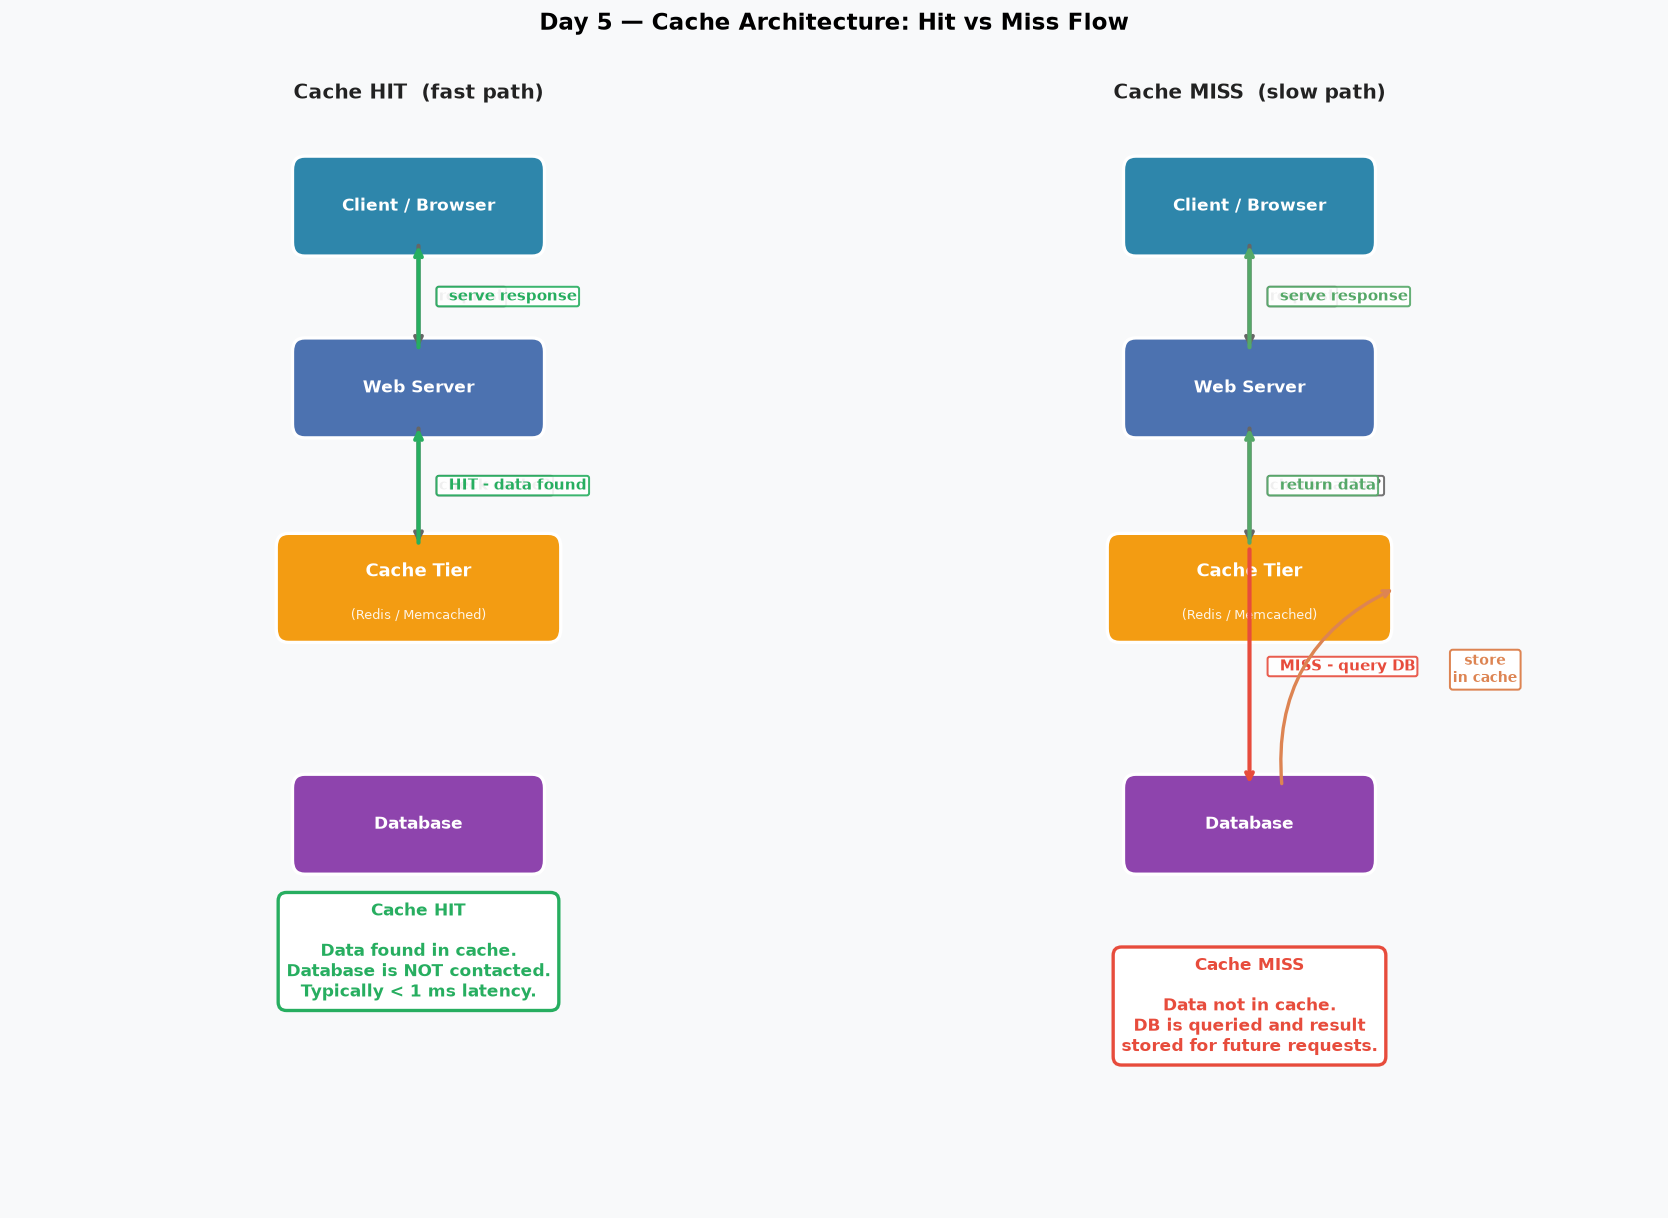

Architecture diagram done.


In [2]:
# Cache architecture: clean vertical flow with hit vs miss paths side-by-side

fig, axes = plt.subplots(1, 2, figsize=(14, 10))
fig.patch.set_facecolor(C_GRAY)

def draw_cache_flow(ax, title, show_hit):
    ax.set_xlim(0, 10)
    ax.set_ylim(0, 12)
    ax.axis('off')
    ax.set_facecolor(C_GRAY)
    ax.set_title(title, fontsize=12, fontweight='bold', pad=10, color='#222')

    def box(x, y, w, h, label, color, fs=10, sub=''):
        r = FancyBboxPatch((x - w/2, y - h/2), w, h,
                           boxstyle='round,pad=0.15',
                           facecolor=color, edgecolor='white', lw=2.0)
        ax.add_patch(r)
        ax.text(x, y + (0.18 if sub else 0), label,
                ha='center', va='center', fontsize=fs,
                fontweight='bold', color='white')
        if sub:
            ax.text(x, y - 0.3, sub, ha='center', va='center',
                    fontsize=8, color='white', alpha=0.9)

    def arrow(x1, y1, x2, y2, color, label='', lw=2.5):
        ax.annotate('', xy=(x2, y2), xytext=(x1, y1),
                    arrowprops=dict(arrowstyle='->', color=color,
                                   lw=lw, connectionstyle='arc3,rad=0'))
        if label:
            mx, my = (x1 + x2) / 2, (y1 + y2) / 2
            ax.text(mx + 0.25, my, label, ha='left', va='center',
                    fontsize=9, color=color, fontweight='bold',
                    bbox=dict(boxstyle='round,pad=0.15', facecolor='white',
                              edgecolor=color, lw=1.2, alpha=0.9))

    # ── Nodes (top to bottom) ────────────────────────────────────────────────
    box(5, 11.0, 2.8, 0.8, 'Client / Browser', C_TEAL, fs=10)
    box(5,  9.0, 2.8, 0.8, 'Web Server', C_WEB, fs=10)
    box(5,  6.8, 3.2, 0.9, 'Cache Tier', C_CACHE, fs=11,
        sub='(Redis / Memcached)')
    box(5,  4.2, 2.8, 0.8, 'Database', C_DB, fs=10)

    # ── Client -> Web Server ─────────────────────────────────────────────────
    arrow(5, 10.6, 5, 9.41, '#666', 'request')

    # ── Web Server -> Cache ──────────────────────────────────────────────────
    arrow(5, 8.59, 5, 7.26, '#666', 'check cache?')

    if show_hit:
        # Cache HIT: response goes straight back up, DB never touched
        arrow(5, 7.26, 5, 8.59, C_HIT, '  HIT - data found')
        arrow(5, 9.41, 5, 10.6, C_HIT, '  serve response')

        ax.text(5, 2.8,
                'Cache HIT\n\nData found in cache.\nDatabase is NOT contacted.\nTypically < 1 ms latency.',
                ha='center', va='center', fontsize=10,
                color=C_HIT, fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.5', facecolor='white',
                          edgecolor=C_HIT, lw=2.0))

    else:
        # Cache MISS: go to DB, store result, then respond
        arrow(5, 7.26, 5, 4.61, C_MISS, '  MISS - query DB')
        # DB result stored in cache
        ax.annotate('', xy=(6.8, 6.8), xytext=(5.4, 4.61),
                    arrowprops=dict(arrowstyle='->', color=C_ORANGE,
                                   lw=2.0, connectionstyle='arc3,rad=-0.35'))
        ax.text(7.9, 5.9, 'store\nin cache', ha='center', va='center',
                fontsize=8.5, color=C_ORANGE, fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.2', facecolor='white',
                          edgecolor=C_ORANGE, lw=1.2))
        # Cache -> Web Server
        arrow(5, 7.26, 5, 8.59, C_GREEN, '  return data')
        # Web Server -> Client
        arrow(5, 9.41, 5, 10.6, C_GREEN, '  serve response')

        ax.text(5, 2.2,
                'Cache MISS\n\nData not in cache.\nDB is queried and result\nstored for future requests.',
                ha='center', va='center', fontsize=10,
                color=C_MISS, fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.5', facecolor='white',
                          edgecolor=C_MISS, lw=2.0))

# Draw both panels
draw_cache_flow(axes[0], 'Cache HIT  (fast path)', show_hit=True)
draw_cache_flow(axes[1], 'Cache MISS  (slow path)', show_hit=False)

plt.suptitle('Day 5 — Cache Architecture: Hit vs Miss Flow',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('/tmp/sd_day5_architecture.png', dpi=130, bbox_inches='tight')
plt.show()
print("Architecture diagram done.")


### What these diagrams show

**Left panel — Cache HIT (fast path):**  
The web server asks the cache for the key. The cache finds it (green arrow) and returns the data immediately. The database is never contacted. The round-trip completes in sub-millisecond time.

**Right panel — Cache MISS (slow path):**  
The cache has no entry for the key. The web server queries the database (red arrow), receives the result, stores it in the cache (orange arc) for future requests, and returns it to the client. The next identical request will be a HIT.

**Key insight:** After the first miss, all subsequent requests for the same key are served from cache until the TTL expires or the key is evicted.

## 3. Caching Strategies

Not all caches work the same way. The strategy determines **who is responsible for populating the cache and when**:

| Strategy | Reads | Writes | Best for |
|---|---|---|---|
| Read-Through | Cache fetches from DB on miss | App writes to DB directly | Read-heavy, simple apps |
| Write-Through | App reads from cache | App writes to cache AND DB atomically | Read-heavy + strong consistency |
| Write-Behind | App reads from cache | App writes to cache; DB updated async | Write-heavy, can tolerate brief data-loss risk |
| Cache-Aside | App checks cache, then DB on miss | App writes to DB; explicitly invalidates cache | Full control, most popular in practice |

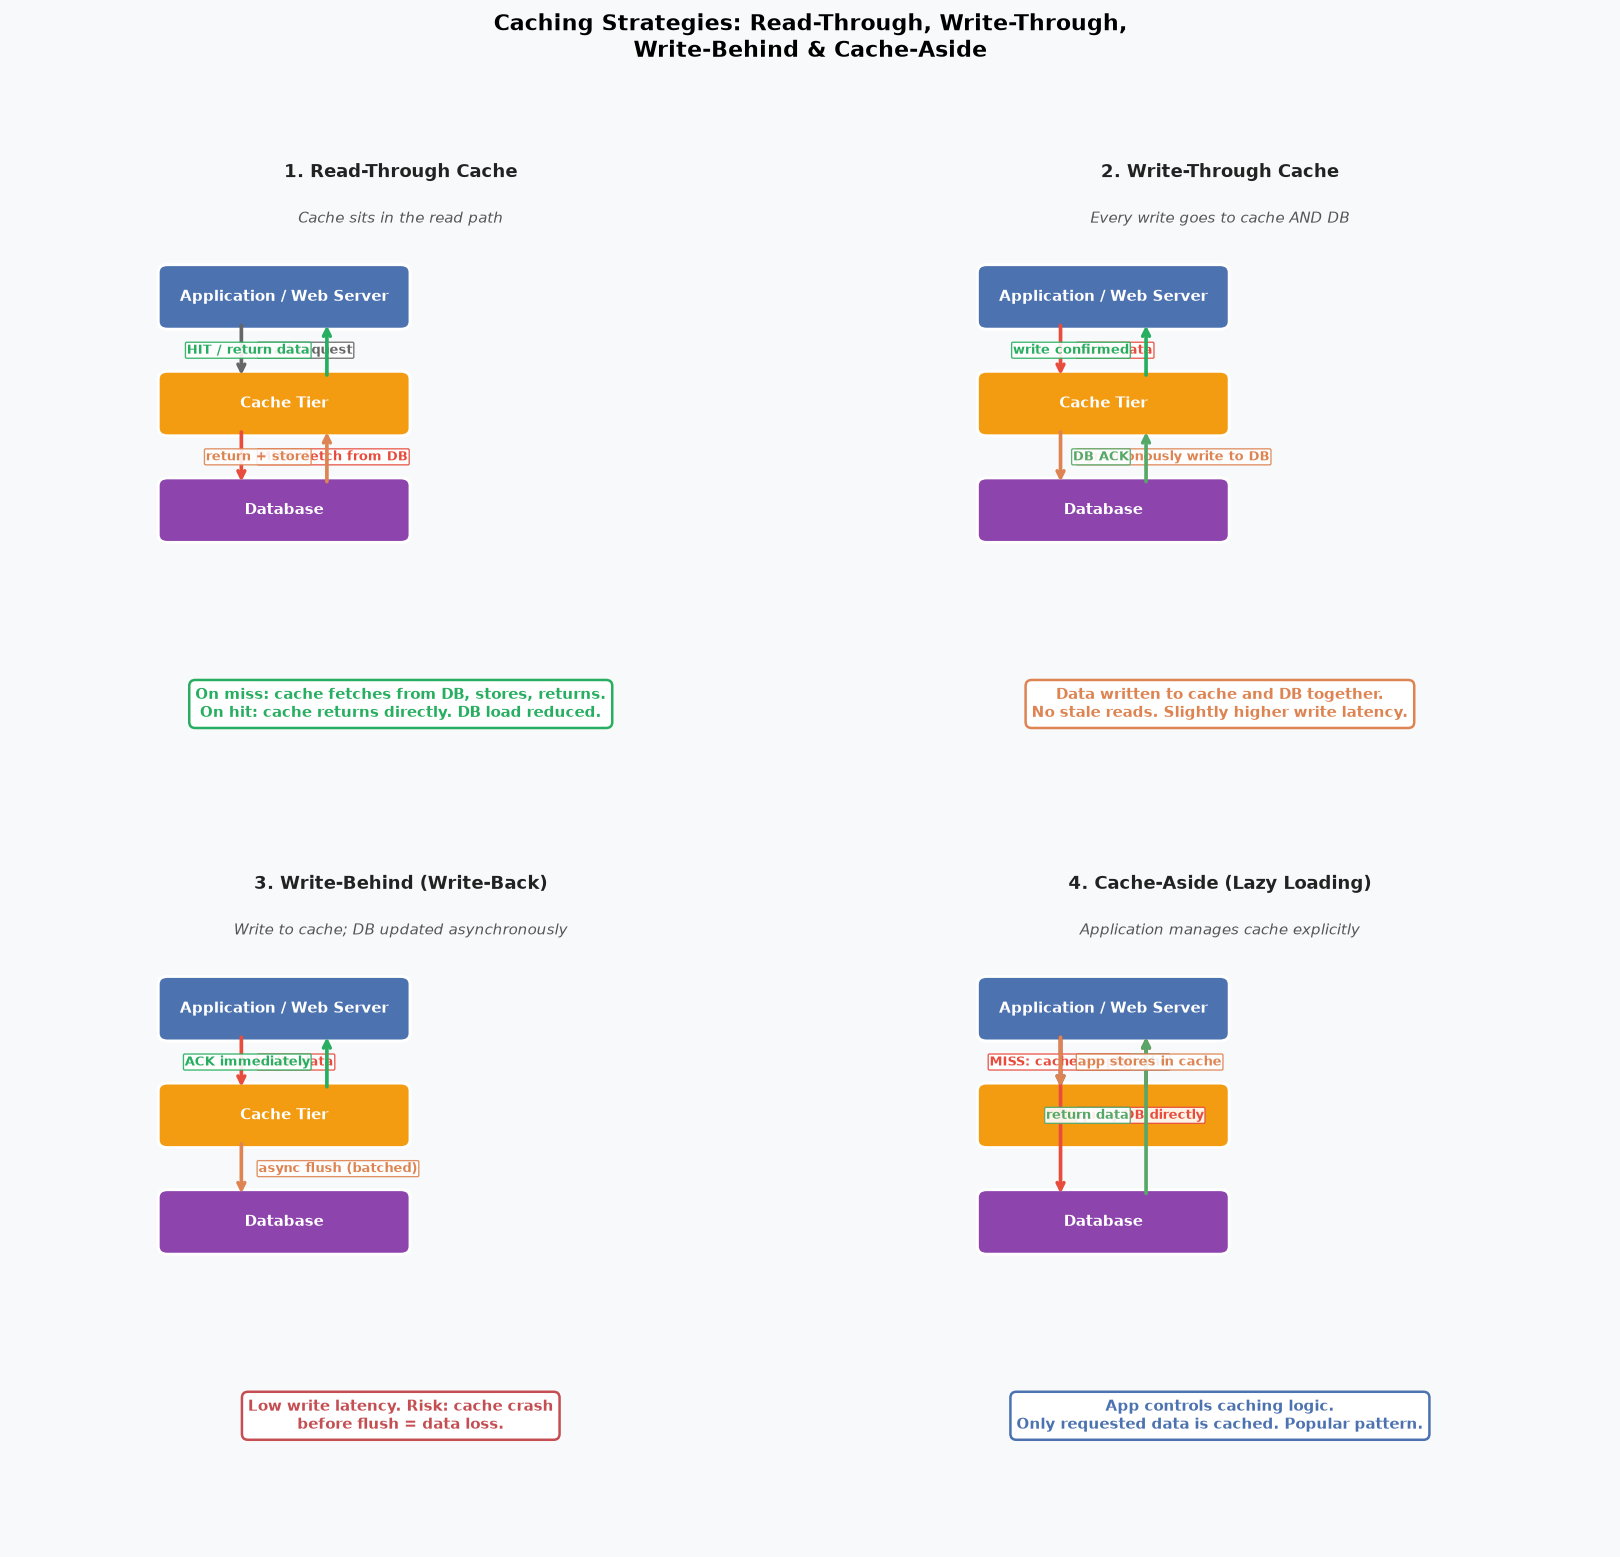

In [3]:
# Caching strategies: Read-Through, Write-Through, Write-Behind, Cache-Aside
# Each shown as a clean vertical/step flow — no crossing arrows

fig, axes = plt.subplots(2, 2, figsize=(14, 13))
fig.patch.set_facecolor(C_GRAY)

strategies = [
    {
        'title': '1. Read-Through Cache',
        'subtitle': 'Cache sits in the read path',
        'steps': [
            ('App', C_WEB,   'Application / Web Server'),
            ('Cache', C_CACHE, 'Cache Tier'),
            ('DB', C_DB,     'Database'),
        ],
        'flows': [
            # (from_idx, to_idx, label, color, direction)
            (0, 1, 'read request', '#666', 'down'),
            (1, 2, 'MISS: fetch from DB', C_MISS, 'down'),
            (2, 1, 'return + store', C_ORANGE, 'up'),
            (1, 0, 'HIT / return data', C_HIT, 'up'),
        ],
        'note': 'On miss: cache fetches from DB, stores, returns.\nOn hit: cache returns directly. DB load reduced.',
        'note_color': C_HIT,
    },
    {
        'title': '2. Write-Through Cache',
        'subtitle': 'Every write goes to cache AND DB',
        'steps': [
            ('App', C_WEB,   'Application / Web Server'),
            ('Cache', C_CACHE, 'Cache Tier'),
            ('DB', C_DB,     'Database'),
        ],
        'flows': [
            (0, 1, 'write data', C_MISS, 'down'),
            (1, 2, 'synchronously write to DB', C_ORANGE, 'down'),
            (2, 1, 'DB ACK', C_GREEN, 'up'),
            (1, 0, 'write confirmed', C_HIT, 'up'),
        ],
        'note': 'Data written to cache and DB together.\nNo stale reads. Slightly higher write latency.',
        'note_color': C_ORANGE,
    },
    {
        'title': '3. Write-Behind (Write-Back)',
        'subtitle': 'Write to cache; DB updated asynchronously',
        'steps': [
            ('App', C_WEB,   'Application / Web Server'),
            ('Cache', C_CACHE, 'Cache Tier'),
            ('DB', C_DB,     'Database'),
        ],
        'flows': [
            (0, 1, 'write data', C_MISS, 'down'),
            (1, 0, 'ACK immediately', C_HIT, 'up'),
            (1, 2, 'async flush (batched)', C_ORANGE, 'down'),
        ],
        'note': 'Low write latency. Risk: cache crash\nbefore flush = data loss.',
        'note_color': C_RED,
    },
    {
        'title': '4. Cache-Aside (Lazy Loading)',
        'subtitle': 'Application manages cache explicitly',
        'steps': [
            ('App', C_WEB,   'Application / Web Server'),
            ('Cache', C_CACHE, 'Cache Tier'),
            ('DB', C_DB,     'Database'),
        ],
        'flows': [
            (0, 1, 'check cache', '#666', 'down'),
            (1, 0, 'MISS: cache empty', C_MISS, 'up'),
            (0, 2, 'query DB directly', C_MISS, 'down'),
            (2, 0, 'return data', C_GREEN, 'up'),
            (0, 1, 'app stores in cache', C_ORANGE, 'down'),
        ],
        'note': 'App controls caching logic.\nOnly requested data is cached. Popular pattern.',
        'note_color': C_BLUE,
    },
]

for ax, s in zip(axes.flat, strategies):
    ax.set_xlim(0, 10)
    ax.set_ylim(0, 10)
    ax.axis('off')
    ax.set_facecolor(C_GRAY)
    ax.set_title(s['title'], fontsize=11, fontweight='bold', color='#222', pad=6)
    ax.text(5, 9.45, s['subtitle'], ha='center', fontsize=9,
            color='#555', fontstyle='italic')

    # Node positions: evenly spaced vertically in the left column
    n = len(s['steps'])
    ys = np.linspace(8.3, 5.0, n)
    node_x = 3.5
    node_positions = {}

    for (key, color, label), y in zip(s['steps'], ys):
        r = FancyBboxPatch((node_x - 1.5, y - 0.38), 3.0, 0.76,
                           boxstyle='round,pad=0.12',
                           facecolor=color, edgecolor='white', lw=1.8)
        ax.add_patch(r)
        ax.text(node_x, y, label, ha='center', va='center',
                fontsize=9, fontweight='bold', color='white')
        node_positions[key] = (node_x, y)

    # Draw arrows with slight horizontal offset for up vs down to avoid overlap
    step_keys = [s['steps'][i][0] for i in range(n)]
    for (fi, ti, label, color, direction) in s['flows']:
        x1, y1 = node_positions[step_keys[fi]]
        x2, y2 = node_positions[step_keys[ti]]

        # Offset down-arrows slightly left, up-arrows slightly right
        dx = -0.55 if direction == 'down' else 0.55
        sx, sy = x1 + dx, y1 + (-0.39 if y2 < y1 else 0.39)
        ex, ey = x2 + dx, y2 + (0.39 if y2 < y1 else -0.39)

        ax.annotate('', xy=(ex, ey), xytext=(sx, sy),
                    arrowprops=dict(arrowstyle='->', color=color, lw=2.2))
        mx, my = (sx + ex) / 2, (sy + ey) / 2
        text_x = mx + (0.22 if direction == 'down' else -0.22)
        ax.text(text_x, my,
                label, ha='left' if direction == 'down' else 'right',
                va='center', fontsize=8, color=color, fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.1', facecolor='white',
                          edgecolor=color, lw=0.8, alpha=0.9))

    ax.text(5, 2.0, s['note'], ha='center', va='center',
            fontsize=9, color=s['note_color'], fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.4', facecolor='white',
                      edgecolor=s['note_color'], lw=1.5))

plt.suptitle('Caching Strategies: Read-Through, Write-Through,\nWrite-Behind & Cache-Aside',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout(pad=2.5)
plt.savefig('/tmp/sd_day5_strategies.png', dpi=130, bbox_inches='tight')
plt.show()


### What these diagrams show

Each panel shows a clean vertical flow between three actors: App, Cache, and DB. Down-arrows (left side of node) represent the request direction; up-arrows (right side) represent responses.

**Read-Through (top-left):** The cache is a transparent proxy. On a MISS the cache fetches and stores the result itself before returning it. The app never speaks to the DB directly.

**Write-Through (top-right):** Every write hits the cache first, then synchronously propagates to the DB. Both stores are updated before the client receives confirmation. Zero cache-DB inconsistency, but slightly higher write latency.

**Write-Behind (bottom-left):** The client receives an ACK as soon as the cache is written. The DB update happens in a background flush (batched or timed). Lowest write latency — but if the cache crashes before flushing, the writes are lost.

**Cache-Aside (bottom-right):** The application fully controls caching logic. On a miss the app queries the DB directly and explicitly populates the cache. This is the **most widely used** pattern (Redis, Memcached typical usage). Gives fine-grained control over what gets cached and for how long.

## 4. Expiration Policy (TTL)

Every cached item should have a **Time-To-Live (TTL)** — a duration after which it is automatically removed.

- **No TTL:** Data is never evicted. Memory grows until the server OOMs, and stale data persists forever.
- **TTL too short (e.g. 5 s):** Cache is constantly evicted; almost every request is a miss; DB load is barely reduced.
- **TTL too long (e.g. 24 h):** Cache is effective, but data can be stale for a long time (e.g. a deleted user still appears cached).

The sweet spot depends on **how often the underlying data changes** and **how much staleness is acceptable**.

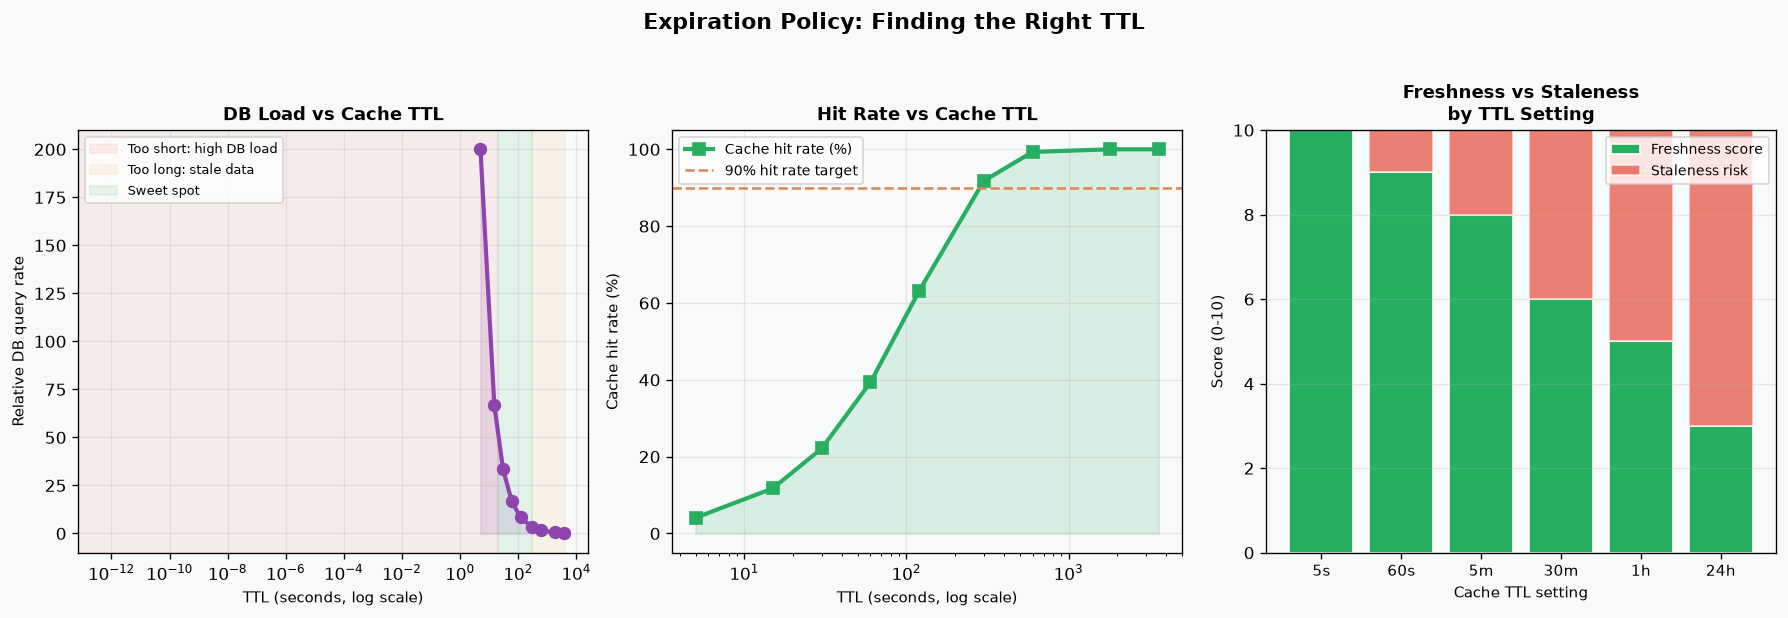

In [4]:
# Expiration policy: effect of TTL on DB load, cache hit rate, and data freshness

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.patch.set_facecolor(C_GRAY)

ttls = np.array([5, 15, 30, 60, 120, 300, 600, 1800, 3600])  # seconds

# ── Left: DB query rate vs TTL ────────────────────────────────────────────────
ax = axes[0]
ax.set_facecolor(C_GRAY)
db_load = 1000 / ttls   # conceptual: fewer cache evictions = fewer DB trips
ax.plot(ttls, db_load, 'o-', color=C_DB, lw=2.5, ms=7)
ax.fill_between(ttls, db_load, alpha=0.15, color=C_DB)

ax.axvspan(0, 20,    alpha=0.08, color=C_MISS,  label='Too short: high DB load')
ax.axvspan(300, 4000, alpha=0.08, color=C_CACHE, label='Too long: stale data')
ax.axvspan(20, 300,   alpha=0.1,  color=C_HIT,   label='Sweet spot')

ax.set_xscale('log')
ax.set_xlabel('TTL (seconds, log scale)', fontsize=9)
ax.set_ylabel('Relative DB query rate', fontsize=9)
ax.set_title('DB Load vs Cache TTL', fontsize=11, fontweight='bold')
ax.legend(fontsize=8)
ax.grid(alpha=0.25)

# ── Middle: cache hit rate curve ─────────────────────────────────────────────
ax = axes[1]
ax.set_facecolor(C_GRAY)
hit_rate = 100 * (1 - np.exp(-ttls / 120))   # sigmoid-ish: hit rate improves with TTL
ax.plot(ttls, hit_rate, 's-', color=C_HIT, lw=2.5, ms=7, label='Cache hit rate (%)')
ax.axhline(90, color=C_ORANGE, lw=1.5, linestyle='--', label='90% hit rate target')
ax.fill_between(ttls, hit_rate, alpha=0.15, color=C_HIT)

ax.set_xscale('log')
ax.set_xlabel('TTL (seconds, log scale)', fontsize=9)
ax.set_ylabel('Cache hit rate (%)', fontsize=9)
ax.set_title('Hit Rate vs Cache TTL', fontsize=11, fontweight='bold')
ax.legend(fontsize=8.5)
ax.grid(alpha=0.25)

# ── Right: staleness bar by TTL band ─────────────────────────────────────────
ax = axes[2]
ax.set_facecolor(C_GRAY)
bands  = ['5s', '60s', '5m', '30m', '1h', '24h']
stale  = [0,    1,     2,    4,     5,    7]    # conceptual staleness score (0-10)
fresh  = [10 - s for s in stale]
x = np.arange(len(bands))

bars_f = ax.bar(x, fresh, color=C_HIT,   edgecolor='white', label='Freshness score')
bars_s = ax.bar(x, stale, bottom=fresh,  color=C_MISS, edgecolor='white', alpha=0.7,
                label='Staleness risk')

ax.set_xticks(x)
ax.set_xticklabels(bands, fontsize=9)
ax.set_xlabel('Cache TTL setting', fontsize=9)
ax.set_ylabel('Score (0-10)', fontsize=9)
ax.set_title('Freshness vs Staleness\nby TTL Setting', fontsize=11, fontweight='bold')
ax.legend(fontsize=8.5)
ax.grid(axis='y', alpha=0.25)

plt.suptitle('Expiration Policy: Finding the Right TTL',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('/tmp/sd_day5_expiration.png', dpi=130, bbox_inches='tight')
plt.show()


### What these charts show

**Left — DB Load vs TTL:** As TTL increases, the cache evicts less frequently, so the DB receives exponentially fewer requests. The red zone (< 20 s TTL) offers almost no protection. The amber zone (> 5 min TTL) delivers most of the benefit but risks stale data.

**Middle — Hit Rate vs TTL:** Cache hit rate rises with TTL. The dashed orange line marks the 90% hit rate target typical for well-tuned production caches. TTLs in the 30 s–5 min range achieve this for most read-heavy workloads.

**Right — Freshness vs Staleness:** The stacked bar shows the trade-off at a glance. Short TTLs are fresh but inefficient; long TTLs are efficient but risk serving outdated data. The right balance is application-specific: financial data needs seconds; a product catalog can tolerate hours.

## 5. Eviction Policies

When the cache is full and a new item must be stored, an **eviction policy** determines which existing item is removed:

| Policy | Evicts | Trade-off |
|---|---|---|
| **LRU** (Least Recently Used) | Item not accessed for longest time | Best general-purpose choice |
| **LFU** (Least Frequently Used) | Item accessed fewest times | Better for power-law distributions |
| **FIFO** (First In, First Out) | Oldest cached item regardless of access | Simple, but ignores access patterns |
| **Random** | Random item | Lowest overhead, worst hit rate |

Redis supports LRU, LFU, and random variants (volatile vs allkeys). LRU is the default and best choice for most use cases.

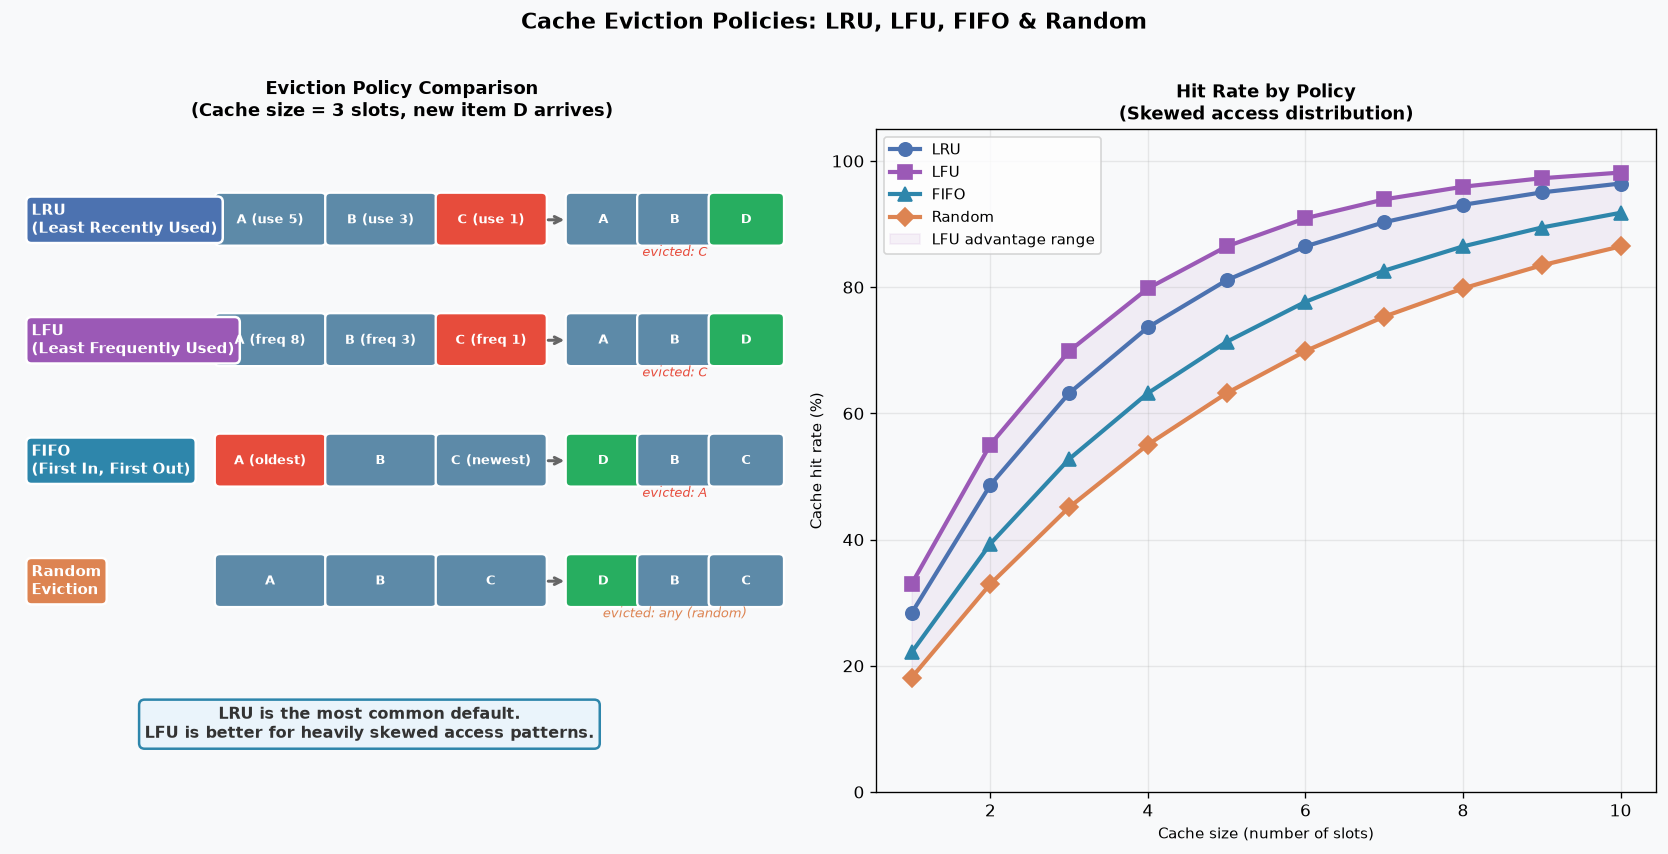

In [5]:
# Eviction policies: LRU, LFU, FIFO, Random — visual comparison

fig, axes = plt.subplots(1, 2, figsize=(14, 7))
fig.patch.set_facecolor(C_GRAY)

# ── Left: cache state walkthrough for each policy ────────────────────────────
ax = axes[0]
ax.set_xlim(0, 12)
ax.set_ylim(0, 11)
ax.axis('off')
ax.set_facecolor(C_GRAY)
ax.set_title('Eviction Policy Comparison\n(Cache size = 3 slots, new item D arrives)',
             fontsize=11, fontweight='bold', pad=8)

policies = ['LRU\n(Least Recently Used)', 'LFU\n(Least Frequently Used)',
            'FIFO\n(First In, First Out)', 'Random\nEviction']
befores  = [['A (use 5)', 'B (use 3)', 'C (use 1)'],
            ['A (freq 8)', 'B (freq 3)', 'C (freq 1)'],
            ['A (oldest)', 'B', 'C (newest)'],
            ['A', 'B', 'C']]
evicted  = ['C',  'C',  'A',  'any (random)']
colors_ev = [C_MISS, C_MISS, C_MISS, C_ORANGE]
policy_colors = [C_BLUE, C_PURPLE, C_TEAL, C_ORANGE]

y_positions = [9.5, 7.5, 5.5, 3.5]
for i, (policy, before, evict, ec, pc) in enumerate(
        zip(policies, befores, evicted, colors_ev, policy_colors)):
    y = y_positions[i]

    # Policy label
    ax.text(0.3, y, policy, ha='left', va='center', fontsize=9,
            fontweight='bold', color='white',
            bbox=dict(boxstyle='round,pad=0.35', facecolor=pc,
                      edgecolor='white', lw=1.5))

    # Before: 3 cache slots
    for j, slot in enumerate(before):
        slot_color = C_MISS if (j == 2 and i < 2) else \
                     C_MISS if (j == 0 and i == 2) else '#5D8AA8'
        r = FancyBboxPatch((3.2 + j*1.7, y - 0.35), 1.55, 0.72,
                           boxstyle='round,pad=0.08',
                           facecolor=slot_color, edgecolor='white', lw=1.4)
        ax.add_patch(r)
        ax.text(3.2 + j*1.7 + 0.77, y, slot, ha='center', va='center',
                fontsize=7.5, color='white', fontweight='bold')

    # Arrow
    ax.annotate('', xy=(8.55, y), xytext=(8.2, y),
                arrowprops=dict(arrowstyle='->', color='#666', lw=1.8))

    # After: evicted slot replaced by D
    after_slots  = before.copy()
    evict_idx    = 2 if i in [0, 1] else 0
    after_slots[evict_idx] = 'D (new)'
    for j, slot in enumerate(after_slots):
        slot_color = C_HIT if slot == 'D (new)' else '#5D8AA8'
        r = FancyBboxPatch((8.6 + j*1.1, y - 0.35), 1.0, 0.72,
                           boxstyle='round,pad=0.08',
                           facecolor=slot_color, edgecolor='white', lw=1.4)
        ax.add_patch(r)
        ax.text(8.6 + j*1.1 + 0.5, y, slot.split(' ')[0], ha='center',
                va='center', fontsize=7.5, color='white', fontweight='bold')

    ax.text(10.2, y - 0.6, f'evicted: {evict}', ha='center', fontsize=7.5,
            color=ec, fontstyle='italic')

ax.text(5.5, 0.9, 'LRU is the most common default.\nLFU is better for heavily skewed access patterns.',
        ha='center', fontsize=9.5, color='#333', fontweight='bold',
        bbox=dict(boxstyle='round,pad=0.35', facecolor='#EAF4FB',
                  edgecolor=C_TEAL, lw=1.5))

# ── Right: hit rate comparison across policies ────────────────────────────────
ax = axes[1]
ax.set_facecolor(C_GRAY)

cache_sizes = np.arange(1, 11)
# Conceptual hit rate curves for different policies on a skewed access distribution
lru_hits  = 100 * (1 - np.exp(-cache_sizes / 3.0))
lfu_hits  = 100 * (1 - np.exp(-cache_sizes / 2.5))   # slightly better on skewed
fifo_hits = 100 * (1 - np.exp(-cache_sizes / 4.0))   # slightly worse
rand_hits = 100 * (1 - np.exp(-cache_sizes / 5.0))   # worst

ax.plot(cache_sizes, lru_hits,  'o-', color=C_BLUE,   lw=2.5, ms=8, label='LRU')
ax.plot(cache_sizes, lfu_hits,  's-', color=C_PURPLE,  lw=2.5, ms=8, label='LFU')
ax.plot(cache_sizes, fifo_hits, '^-', color=C_TEAL,   lw=2.5, ms=8, label='FIFO')
ax.plot(cache_sizes, rand_hits, 'D-', color=C_ORANGE, lw=2.5, ms=8, label='Random')

ax.fill_between(cache_sizes, rand_hits, lfu_hits, alpha=0.08, color=C_PURPLE,
                label='LFU advantage range')

ax.set_xlabel('Cache size (number of slots)', fontsize=9)
ax.set_ylabel('Cache hit rate (%)', fontsize=9)
ax.set_title('Hit Rate by Policy\n(Skewed access distribution)',
             fontsize=11, fontweight='bold')
ax.legend(fontsize=9)
ax.grid(alpha=0.25)
ax.set_ylim(0, 105)

plt.suptitle('Cache Eviction Policies: LRU, LFU, FIFO & Random',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('/tmp/sd_day5_eviction.png', dpi=130, bbox_inches='tight')
plt.show()


### What these diagrams show

**Left — Policy walkthrough (cache size = 3, new item D arrives):**  
Each row shows which item gets evicted and why:
- **LRU:** C was least recently used (access count 1) → C evicted
- **LFU:** C has lowest frequency (freq 1) → C evicted
- **FIFO:** A was inserted first (oldest) → A evicted regardless of access frequency
- **Random:** Any slot may be chosen — unpredictable

The gold border highlights the promoted new item D in each scenario.

**Right — Hit rate comparison (skewed access distribution):**  
LFU outperforms LRU when a small fraction of keys dominate access (Pareto distribution) — the 20% most-popular keys get 80% of the reads. LFU keeps them in cache longer. For more uniform access distributions, LRU and LFU perform similarly.

## 6. Consistency & Mitigating SPOF

**Consistency problem:** The cache and database can diverge when writes happen outside a single transaction:
1. App updates DB ✓
2. App tries to invalidate cache key — but crashes before completing ✗
3. Cache still holds the old value → stale reads for TTL duration

**Fix options:**
- Atomic cache+DB update (use transactions or Lua scripts in Redis)
- Write-through caching (DB and cache always written together)
- Accept brief staleness + set a short TTL as a self-healing mechanism

**SPOF:** A single cache server going down means every request becomes a miss, overwhelming the database. Solution: run a **cache cluster** with consistent hashing to distribute keys across nodes.

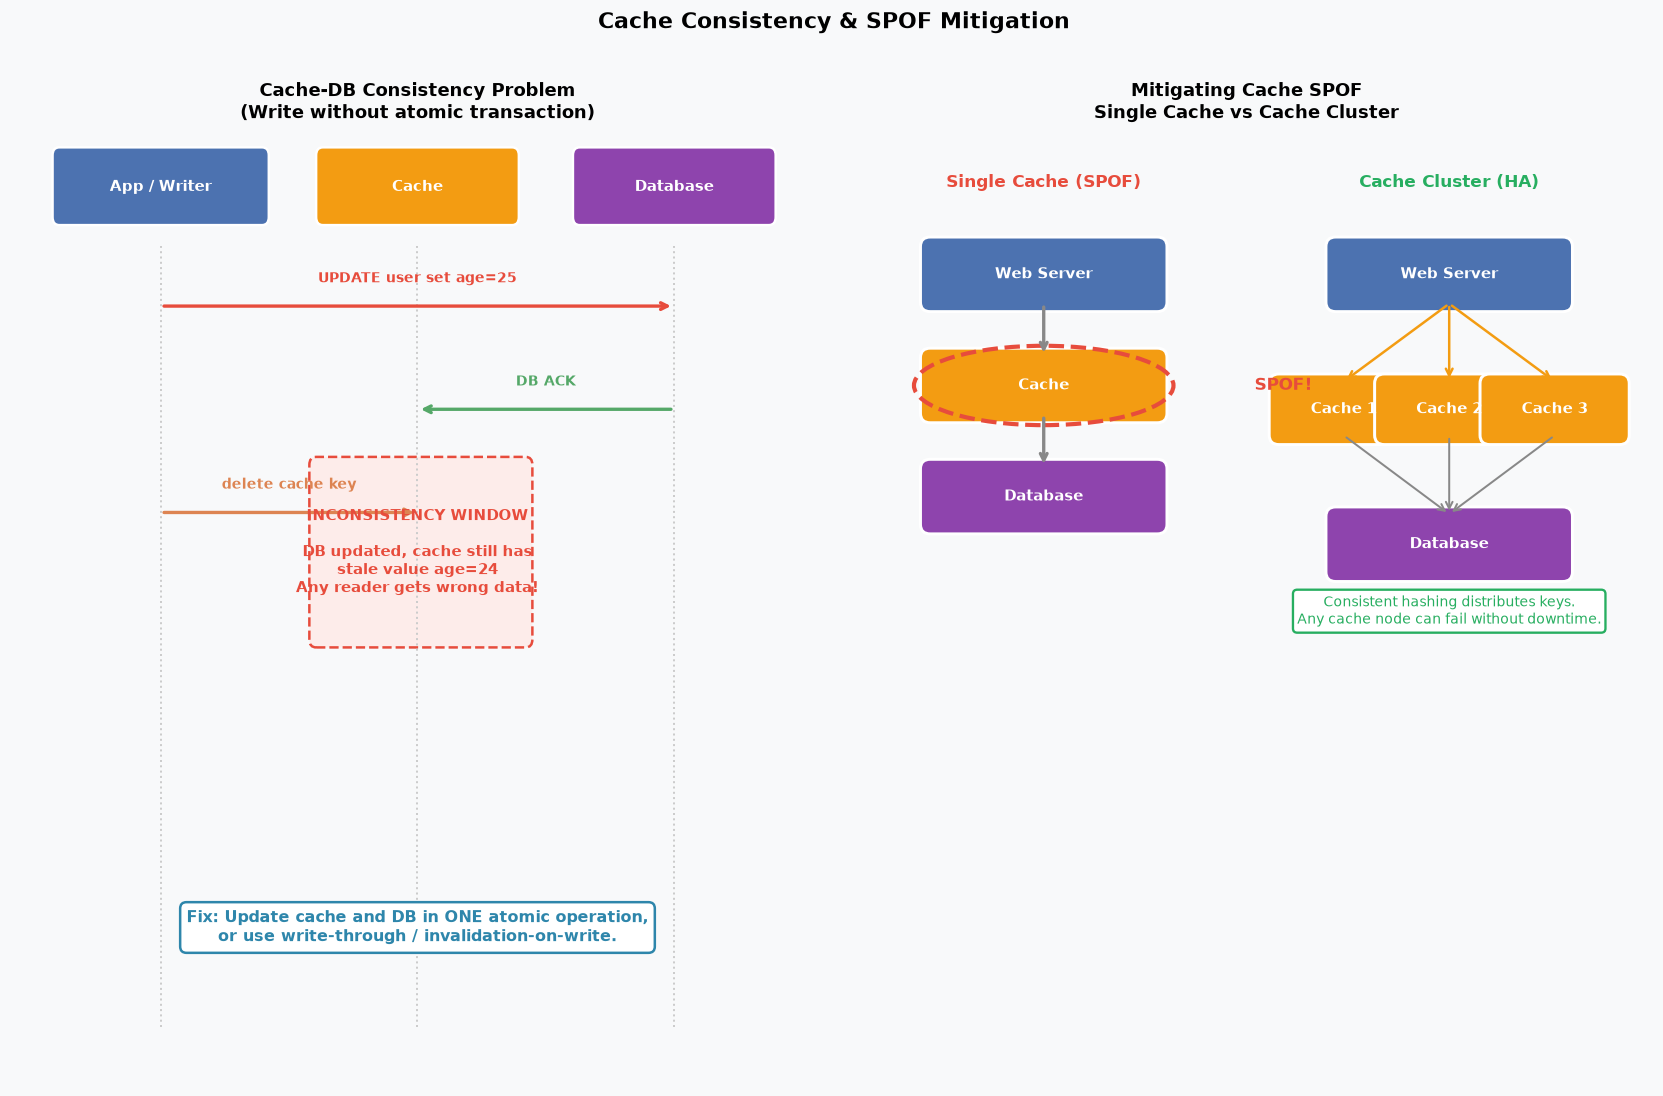

In [6]:
# Consistency & SPOF: cache-DB sync problem + single vs multi-cache setup

fig, axes = plt.subplots(1, 2, figsize=(14, 9))
fig.patch.set_facecolor(C_GRAY)

# ── Left: consistency timeline ────────────────────────────────────────────────
ax = axes[0]
ax.set_xlim(0, 12)
ax.set_ylim(0, 12)
ax.axis('off')
ax.set_facecolor(C_GRAY)
ax.set_title('Cache-DB Consistency Problem\n(Write without atomic transaction)',
             fontsize=11, fontweight='bold', pad=8)

def timeline_box(ax, x, y, w, label, color, fs=9):
    r = FancyBboxPatch((x - w/2, y - 0.38), w, 0.78,
                       boxstyle='round,pad=0.1',
                       facecolor=color, edgecolor='white', lw=1.5)
    ax.add_patch(r)
    ax.text(x, y, label, ha='center', va='center',
            fontsize=fs, fontweight='bold', color='white')

# Actors
timeline_box(ax, 2.2, 11.3, 3.0, 'App / Writer', C_WEB)
timeline_box(ax, 6.0, 11.3, 2.8, 'Cache',        C_CACHE)
timeline_box(ax, 9.8, 11.3, 2.8, 'Database',     C_DB)

# Lifelines
for x in [2.2, 6.0, 9.8]:
    ax.axvline(x, ymin=0.06, ymax=0.88, color='#CCC', lw=1.2, linestyle=':')

events = [
    (2.2, 9.8, 'UPDATE user set age=25', C_MISS,   'write to DB',    9.8, 10.0, C_DB),
    (9.8, 6.0, 'DB ACK',                  C_GREEN,  None,             None, None, None),
    (2.2, 6.0, 'delete cache key',        C_ORANGE, 'invalidate',     6.0, 8.9, C_CACHE),
]

y_steps = [9.8, 8.5, 7.2]
for (step_idx, (x_from, x_to, lbl, color, sublbl, bx, by, bc)) in enumerate(events):
    y = y_steps[step_idx]
    ax.annotate('', xy=(x_to, y), xytext=(x_from, y),
                arrowprops=dict(arrowstyle='->', color=color, lw=2.0))
    ax.text((x_from + x_to)/2, y + 0.3, lbl, ha='center', fontsize=8.5,
            color=color, fontweight='bold')

# Inconsistency window shading
ax.add_patch(FancyBboxPatch((4.5, 5.6), 3.1, 2.2,
             boxstyle='round,pad=0.1',
             facecolor='#FDECEA', edgecolor=C_MISS, lw=1.5, linestyle='--'))
ax.text(6.0, 6.7, 'INCONSISTENCY WINDOW\n\nDB updated, cache still has\nstale value age=24\n'
        'Any reader gets wrong data!',
        ha='center', va='center', fontsize=9, color=C_MISS, fontweight='bold')

ax.text(6.0, 1.8,
        'Fix: Update cache and DB in ONE atomic operation,\nor use write-through / invalidation-on-write.',
        ha='center', fontsize=9.5, color=C_TEAL, fontweight='bold',
        bbox=dict(boxstyle='round,pad=0.4', facecolor='white',
                  edgecolor=C_TEAL, lw=1.5))

# ── Right: SPOF -> multiple cache servers ─────────────────────────────────────
ax = axes[1]
ax.set_xlim(0, 10)
ax.set_ylim(0, 12)
ax.axis('off')
ax.set_facecolor(C_GRAY)
ax.set_title('Mitigating Cache SPOF\nSingle Cache vs Cache Cluster',
             fontsize=11, fontweight='bold', pad=8)

def draw_box(ax, x, y, w, h, label, color, sub=''):
    r = FancyBboxPatch((x - w/2, y - h/2), w, h,
                       boxstyle='round,pad=0.12',
                       facecolor=color, edgecolor='white', lw=1.8)
    ax.add_patch(r)
    ax.text(x, y + (0.18 if sub else 0), label, ha='center', va='center',
            fontsize=9, fontweight='bold', color='white')
    if sub:
        ax.text(x, y - 0.3, sub, ha='center', va='center',
                fontsize=7.5, color='white', alpha=0.9)

# ── Bad: single cache ─────────────────────────────────────────────────────────
ax.text(2.5, 11.3, 'Single Cache (SPOF)', ha='center', fontsize=10,
        fontweight='bold', color=C_MISS)
draw_box(ax, 2.5, 10.2, 2.8, 0.7, 'Web Server', C_WEB)
draw_box(ax, 2.5,  8.8, 2.8, 0.7, 'Cache', C_CACHE)
draw_box(ax, 2.5,  7.4, 2.8, 0.7, 'Database', C_DB)
ax.annotate('', xy=(2.5, 9.17), xytext=(2.5, 9.83),
            arrowprops=dict(arrowstyle='->', color='#888', lw=2))
ax.annotate('', xy=(2.5, 7.77), xytext=(2.5, 8.43),
            arrowprops=dict(arrowstyle='->', color='#888', lw=2))
# SPOF label
ax.text(2.5, 8.8, '', ha='center')
ax.add_patch(plt.matplotlib.patches.Ellipse((2.5, 8.8), 3.2, 1.0,
             fill=False, edgecolor=C_MISS, lw=2.5, linestyle='--'))
ax.text(5.1, 8.8, 'SPOF!', ha='left', va='center',
        fontsize=10, color=C_MISS, fontweight='bold')

# ── Good: cache cluster ───────────────────────────────────────────────────────
ax.text(7.5, 11.3, 'Cache Cluster (HA)', ha='center', fontsize=10,
        fontweight='bold', color=C_HIT)
draw_box(ax, 7.5, 10.2, 2.8, 0.7, 'Web Server', C_WEB)
for cx, cy, lbl in [(6.2, 8.5, 'Cache 1'), (7.5, 8.5, 'Cache 2'), (8.8, 8.5, 'Cache 3')]:
    draw_box(ax, cx, cy, 1.6, 0.65, lbl, C_CACHE)
    ax.annotate('', xy=(cx, 8.85), xytext=(7.5, 9.83),
                arrowprops=dict(arrowstyle='->', color=C_CACHE, lw=1.5))
draw_box(ax, 7.5, 6.8, 2.8, 0.7, 'Database', C_DB)
for cx in [6.2, 7.5, 8.8]:
    ax.annotate('', xy=(7.5, 7.18), xytext=(cx, 8.17),
                arrowprops=dict(arrowstyle='->', color='#888', lw=1.2))
ax.text(7.5, 5.8, 'Consistent hashing distributes keys.\nAny cache node can fail without downtime.',
        ha='center', fontsize=8.5, color=C_HIT,
        bbox=dict(boxstyle='round,pad=0.3', facecolor='white',
                  edgecolor=C_HIT, lw=1.4))

plt.suptitle('Cache Consistency & SPOF Mitigation',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('/tmp/sd_day5_consistency_spof.png', dpi=130, bbox_inches='tight')
plt.show()


### What these diagrams show

**Left — Consistency timeline:**  
The dashed red box marks the **inconsistency window** — the period between the DB write completing and the cache invalidation completing. Any reader during this window gets stale data. The shorter this window, the safer the system.

**Right — SPOF vs Cache Cluster:**  
The single cache (dashed red circle) is a single point of failure — one crash sends all traffic to the database. The cache cluster (right) uses **consistent hashing**: each key is assigned to a node based on a hash ring. If one node fails, only its keys miss; the rest of the cluster continues serving. Redis Cluster and Memcached with a proxy (Twemproxy) implement this.

## 7. When to Use Cache

Cache is not appropriate for every situation. The decision depends on:

1. **Read vs write ratio** — cache shines when reads >> writes
2. **Data update frequency** — frequently changing data is hard to keep consistent
3. **Tolerance for stale data** — financial and inventory systems need high accuracy
4. **Compute cost** — expensive aggregations and ML predictions are ideal cache candidates

**Rule of thumb:** If you call it twice and it's the same answer both times, cache it.

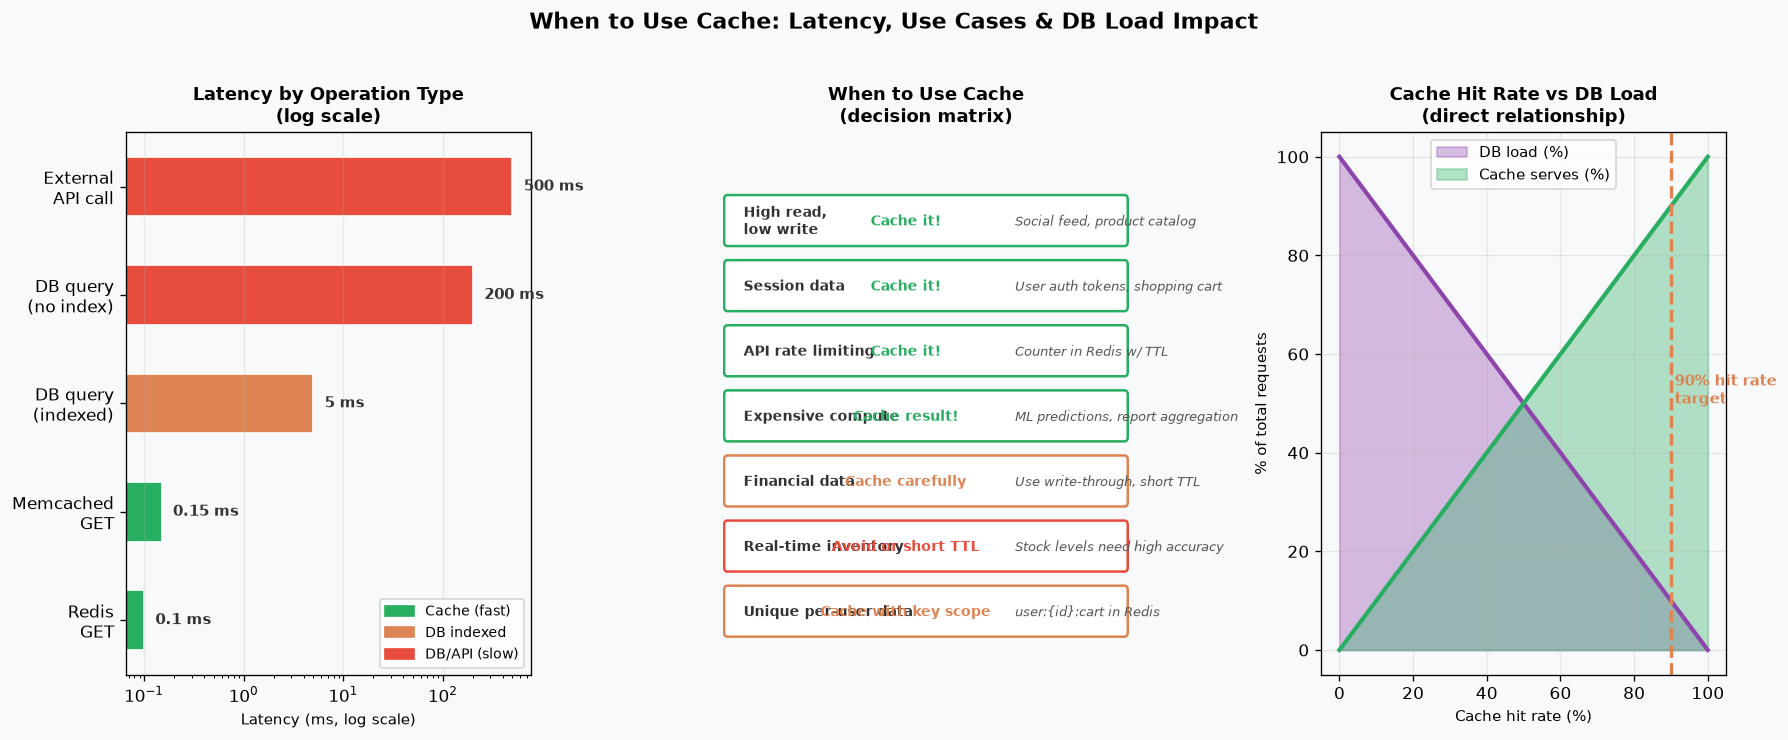

In [7]:
# When to use cache + performance impact charts

fig, axes = plt.subplots(1, 3, figsize=(15, 6))
fig.patch.set_facecolor(C_GRAY)

# ── Left: latency comparison — with and without cache ────────────────────────
ax = axes[0]
ax.set_facecolor(C_GRAY)

operations = ['Redis\nGET', 'Memcached\nGET', 'DB query\n(indexed)', 'DB query\n(no index)',
              'External\nAPI call']
latency_ms = [0.1, 0.15, 5, 200, 500]
colors_lat = [C_HIT, C_HIT, C_ORANGE, C_MISS, C_MISS]

bars = ax.barh(operations, latency_ms, color=colors_lat,
               edgecolor='white', height=0.55)
ax.set_xscale('log')
ax.set_xlabel('Latency (ms, log scale)', fontsize=9)
ax.set_title('Latency by Operation Type\n(log scale)', fontsize=11, fontweight='bold')
ax.grid(axis='x', alpha=0.25)

for bar, val in zip(bars, latency_ms):
    ax.text(val * 1.3, bar.get_y() + bar.get_height()/2,
            f'{val} ms', va='center', fontsize=9, fontweight='bold', color='#333')

handles = [mpatches.Patch(color=C_HIT, label='Cache (fast)'),
           mpatches.Patch(color=C_ORANGE, label='DB indexed'),
           mpatches.Patch(color=C_MISS, label='DB/API (slow)')]
ax.legend(handles=handles, fontsize=8.5, loc='lower right')

# ── Middle: use-case decision matrix ─────────────────────────────────────────
ax = axes[1]
ax.set_facecolor(C_GRAY)
ax.set_xlim(0, 10); ax.set_ylim(0, 10)
ax.axis('off')
ax.set_title('When to Use Cache\n(decision matrix)', fontsize=11, fontweight='bold')

use_cases = [
    ('High read,\nlow write', C_HIT,    'Cache it!',            'Social feed, product catalog'),
    ('Session data',          C_HIT,    'Cache it!',            'User auth tokens, shopping cart'),
    ('API rate limiting',     C_HIT,    'Cache it!',            'Counter in Redis w/ TTL'),
    ('Expensive compute',     C_HIT,    'Cache result!',        'ML predictions, report aggregation'),
    ('Financial data',        C_ORANGE, 'Cache carefully',      'Use write-through, short TTL'),
    ('Real-time inventory',   C_MISS,   'Avoid or short TTL',   'Stock levels need high accuracy'),
    ('Unique per-user data',  C_ORANGE, 'Cache with key scope', 'user:{id}:cart in Redis'),
]

y0 = 9.5
for (label, color, verdict, example) in use_cases:
    y0 -= 1.2
    r = FancyBboxPatch((0.1, y0 - 0.32), 9.8, 0.78,
                       boxstyle='round,pad=0.08',
                       facecolor='white', edgecolor=color, lw=1.5)
    ax.add_patch(r)
    ax.text(0.5, y0 + 0.05, label, ha='left', va='center',
            fontsize=8.5, fontweight='bold', color='#333')
    ax.text(4.5, y0 + 0.05, verdict, ha='center', va='center',
            fontsize=8.5, fontweight='bold', color=color)
    ax.text(7.2, y0 + 0.05, example, ha='left', va='center',
            fontsize=7.5, color='#555', fontstyle='italic')

# ── Right: hit rate impact on DB load ────────────────────────────────────────
ax = axes[2]
ax.set_facecolor(C_GRAY)
hit_rates = np.arange(0, 101, 5)
db_load   = 100 - hit_rates   # DB receives (100 - hit_rate)% of requests
savings   = hit_rates          # % of requests served from cache

ax.fill_between(hit_rates, db_load, color=C_DB, alpha=0.35, label='DB load (%)')
ax.fill_between(hit_rates, savings, color=C_HIT, alpha=0.35, label='Cache serves (%)')
ax.plot(hit_rates, db_load, '-', color=C_DB, lw=2.5)
ax.plot(hit_rates, savings, '-', color=C_HIT, lw=2.5)

ax.axvline(90, color=C_ORANGE, lw=2, linestyle='--')
ax.text(91, 50, '90% hit rate\ntarget', fontsize=9, color=C_ORANGE, fontweight='bold')

ax.set_xlabel('Cache hit rate (%)', fontsize=9)
ax.set_ylabel('% of total requests', fontsize=9)
ax.set_title('Cache Hit Rate vs DB Load\n(direct relationship)',
             fontsize=11, fontweight='bold')
ax.legend(fontsize=9)
ax.grid(alpha=0.25)

plt.suptitle('When to Use Cache: Latency, Use Cases & DB Load Impact',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('/tmp/sd_day5_when_to_use.png', dpi=130, bbox_inches='tight')
plt.show()


### What these charts show

**Left — Latency comparison:**  
Redis/Memcached GET operations complete in ~0.1–0.15 ms. An indexed DB query takes ~5 ms — 50× slower. An unindexed query or external API call can be 1000–5000× slower than a cache hit. This is the core justification for caching: latency reduction.

**Middle — Use-case decision matrix:**  
Green rows are ideal cache candidates (high read, low write, or expensive to compute). Orange rows require care — cache with short TTL or write-through to avoid stale reads. Red rows should avoid caching or use very short TTLs (real-time inventory accuracy matters more than speed).

**Right — Hit rate vs DB load:**  
The relationship is direct and linear: a 90% cache hit rate means only 10% of requests reach the DB. This is why the 90% hit rate is the standard production target. Most well-configured caches for read-heavy workloads exceed 95%.

## 8. Architecture Evolution & Scorecard

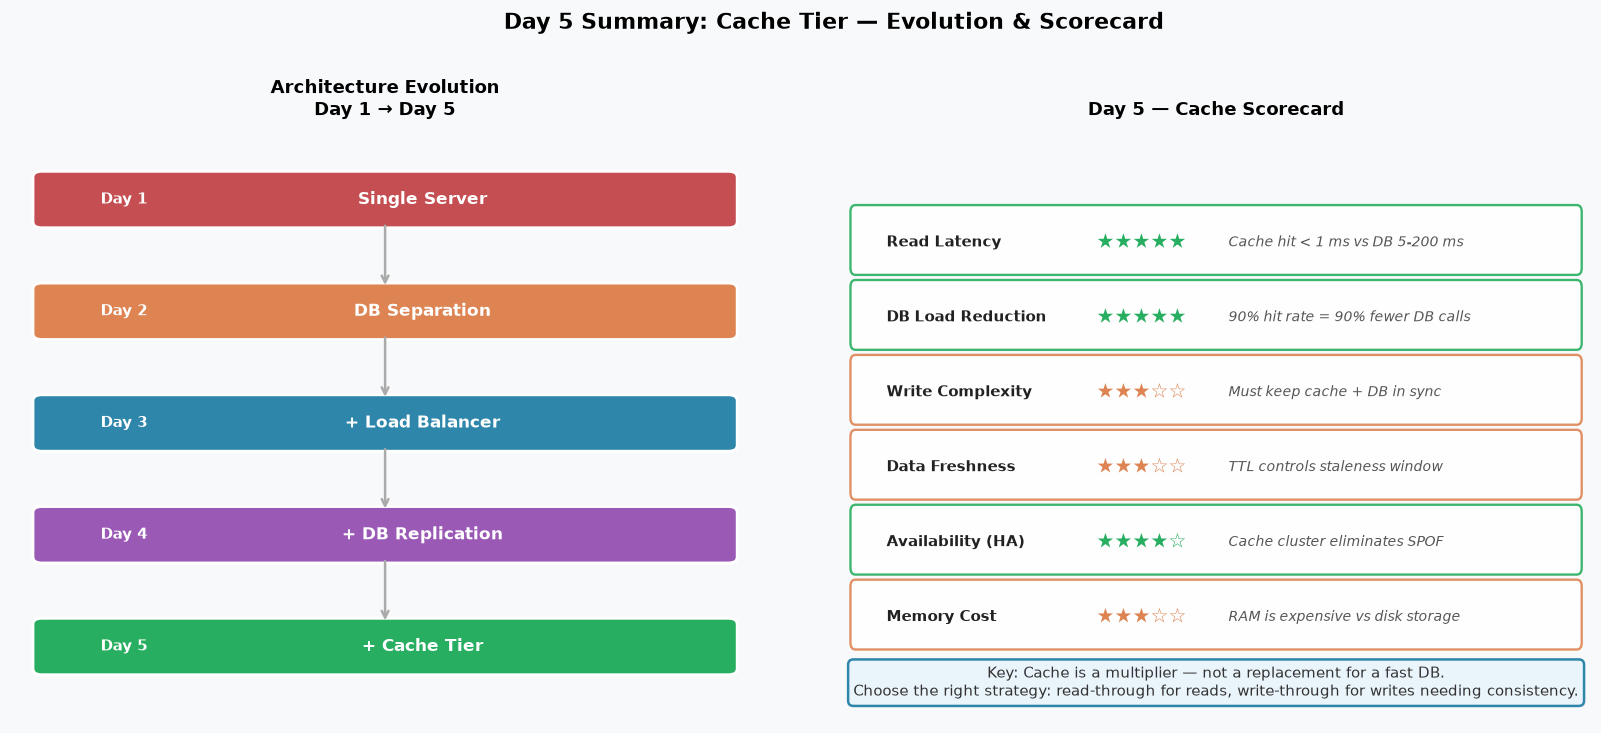

Day 5 complete.


In [8]:
# Day 5 Scorecard + Evolution Day 1 -> 5

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.patch.set_facecolor(C_GRAY)

# ── Left: evolution diagram ────────────────────────────────────────────────────
ax = axes[0]
ax.set_xlim(0, 10); ax.set_ylim(0, 12)
ax.axis('off'); ax.set_facecolor(C_GRAY)
ax.set_title('Architecture Evolution\nDay 1 → Day 5', fontsize=11, fontweight='bold')

days = [
    ('Day 1', 'Single Server',     C_RED),
    ('Day 2', 'DB Separation',     C_ORANGE),
    ('Day 3', '+ Load Balancer',   C_TEAL),
    ('Day 4', '+ DB Replication',  C_PURPLE),
    ('Day 5', '+ Cache Tier',      C_HIT),
]
ys = np.linspace(10.5, 1.5, len(days))
for i, ((day, label, color), y) in enumerate(zip(days, ys)):
    r = FancyBboxPatch((0.4, y - 0.45), 9.2, 0.9,
                       boxstyle='round,pad=0.12',
                       facecolor=color, edgecolor='white', lw=1.8)
    ax.add_patch(r)
    ax.text(1.5, y, day, ha='center', va='center',
            fontsize=9, fontweight='bold', color='white')
    ax.text(5.5, y, label, ha='center', va='center',
            fontsize=10, fontweight='bold', color='white')
    if i < len(days) - 1:
        ax.annotate('', xy=(5, ys[i+1] + 0.46), xytext=(5, y - 0.46),
                    arrowprops=dict(arrowstyle='->', color='#aaa', lw=1.5))

# ── Right: scorecard ──────────────────────────────────────────────────────────
ax = axes[1]
ax.set_xlim(0, 12); ax.set_ylim(0, 7)
ax.axis('off'); ax.set_facecolor(C_GRAY)
ax.set_title('Day 5 — Cache Scorecard', fontsize=11, fontweight='bold')

metrics = [
    ('Read Latency',          '★★★★★', C_HIT,    'Cache hit < 1 ms vs DB 5-200 ms'),
    ('DB Load Reduction',     '★★★★★', C_HIT,    '90% hit rate = 90% fewer DB calls'),
    ('Write Complexity',      '★★★☆☆', C_ORANGE, 'Must keep cache + DB in sync'),
    ('Data Freshness',        '★★★☆☆', C_ORANGE, 'TTL controls staleness window'),
    ('Availability (HA)',     '★★★★☆', C_HIT,    'Cache cluster eliminates SPOF'),
    ('Memory Cost',           '★★★☆☆', C_ORANGE, 'RAM is expensive vs disk storage'),
]

y0 = 6.5
for (metric, stars, color, detail) in metrics:
    y0 -= 0.88
    r = FancyBboxPatch((0.2, y0 - 0.3), 11.6, 0.66,
                       boxstyle='round,pad=0.08',
                       facecolor='white', edgecolor=color, lw=1.4, alpha=0.9)
    ax.add_patch(r)
    ax.text(0.7,  y0, metric, ha='left',   va='center', fontsize=9,  fontweight='bold', color='#222')
    ax.text(4.8,  y0, stars,  ha='center', va='center', fontsize=12, color=color)
    ax.text(6.2,  y0, detail, ha='left',   va='center', fontsize=8.5, color='#555', fontstyle='italic')

ax.text(6, 0.45,
        'Key: Cache is a multiplier — not a replacement for a fast DB.\n'
        'Choose the right strategy: read-through for reads, write-through for writes needing consistency.',
        ha='center', va='center', fontsize=9, color='#333',
        bbox=dict(boxstyle='round,pad=0.35', facecolor='#EAF4FB',
                  edgecolor=C_TEAL, lw=1.5))

plt.suptitle('Day 5 Summary: Cache Tier — Evolution & Scorecard',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('/tmp/sd_day5_scorecard.png', dpi=130, bbox_inches='tight')
plt.show()
print("Day 5 complete.")


### What this shows

**Left — Evolution Day 1 → Day 5:**  
Each day adds one capability. By Day 5 the architecture handles horizontal web scaling (Day 3), read DB scaling (Day 4), and now read latency (Day 5). The progression is deliberate: each layer addresses the previous bottleneck.

**Right — Day 5 Scorecard:**  
- **Read Latency (5/5):** Sub-millisecond hits vs 5–200 ms DB queries — the single biggest performance win.
- **DB Load Reduction (5/5):** At 90% hit rate, only 1 in 10 requests touches the DB.
- **Write Complexity (3/5):** Cache invalidation is notoriously hard — must be designed carefully.
- **Data Freshness (3/5):** TTL-based expiry introduces a staleness window.
- **Availability (4/5):** Cache cluster with consistent hashing eliminates single-node SPOF.
- **Memory Cost (3/5):** RAM is 10–100× more expensive per GB than SSD — cache only what earns its keep.

**Bottom line:** Cache is one of the highest-leverage system design tools. Master it early, but always design the write path carefully to avoid consistency surprises.